In [21]:
from dotenv import load_dotenv
import os 
import numpy as np
import pandas as pd
import json

load_dotenv()

annotations=os.getenv('ANNOTATION_DIR')
path = annotations + '\\train_annotations.json'

def corresponding(file_names, img_value):
    name = next(file['name'] for file in file_names if file['id'] == img_value)
    print(name)
    return name

def get_images():
    '''
    Goes through every image and gets IDs of categories and 
    attributes. Stores everything in a dict
    '''
    images_temp = [] # Temporary hold all dicts before processing
    file_names = []

    with open(path, 'r', encoding='utf-8') as t:
        file = json.load(t)

    # They are just IDs so need to decode them later on
    for i in range(45623): # How many images in train
        values = {'image_id' : file['annotations'][i]['image_id'], 
                  'attribute_id' : file['annotations'][i]['attribute_ids'],
                  'category_id' : file['annotations'][i]['category_id'],
                  'bbox' : file['annotations'][i]['bbox']}

        images_temp.append(values)

    for j in range(45623): # How many images in train
        # Get file name and ID to match the other list with
        file_names.append({'name' : file['images'][j]['file_name'], 
                           'id' : file['images'][j]['id']})

    return file_names, images_temp

def process_values(file_names, images_temp):
    images = {}
    for value in images_temp:
        id = value['image_id']
        name = corresponding(file_names, id)
        images[name] = value
        
    return images

def get_cat(id, cats):
    cat = next(c['name'] for c in cats if c['id'] == id)
    return cat

def get_attr(attr_id, attrs):
    names = []
    
    for id in attr_id:
        names.append(next(a['name'] for a in attrs if a['id'] == id))

    return names

def decode_images(images):
    processed = {}

    # Decodes all of the IDs for each image
    with open(path, 'r', encoding='utf-8') as t:
        file = json.load(t)

    # Each image has 0 or more attributes in a list
    # Each image has only one category
    categories = file['categories']
    attributes = file['attributes']

    for img in images:
        cat = get_cat(images[img]['category_id'], categories)
        describe = images[img]['attribute_id']
        bbox = images[img]['bbox'] # No need to process this. Used to find stuff later

        if describe: # Not every img has an attribute
            attr = get_attr(describe, attributes)
        else:
            attr = None

        processed[img] = [cat, attr, bbox]
    return processed

In [24]:
file_names, images_temp = get_images()


In [25]:
len(file_names)

45623

In [30]:
idk = []
for i in file_names:
    if i['name'] == '2f10b4d61e445fe5d0777723630a2905.jpg':
        idk.append(i['name'])

In [37]:
type(file_names)

list

There are no duplicates in file names. The problem is within the code itself perhaps.

In [39]:
file_names

unique = [dict(t) for t in {frozenset(d.items()) for d in file_names}]

In [40]:
len(unique)

45623

In [35]:
len(file_names['name'])

TypeError: list indices must be integers or slices, not str

In [22]:
file_names, images_temp = get_images()
process_values(file_names, images_temp)
#processed = decode_images(images)


2f10b4d61e445fe5d0777723630a2905.jpg
2f10b4d61e445fe5d0777723630a2905.jpg
2f10b4d61e445fe5d0777723630a2905.jpg
2f10b4d61e445fe5d0777723630a2905.jpg
2f10b4d61e445fe5d0777723630a2905.jpg
2f10b4d61e445fe5d0777723630a2905.jpg
2f10b4d61e445fe5d0777723630a2905.jpg
22a8ea3f355d653b5d857a3ba3a597c2.jpg
22a8ea3f355d653b5d857a3ba3a597c2.jpg
22a8ea3f355d653b5d857a3ba3a597c2.jpg
22a8ea3f355d653b5d857a3ba3a597c2.jpg
22a8ea3f355d653b5d857a3ba3a597c2.jpg
22a8ea3f355d653b5d857a3ba3a597c2.jpg
22a8ea3f355d653b5d857a3ba3a597c2.jpg
e2dff3ef4e09d5c6389f217a73db57bd.jpg
e2dff3ef4e09d5c6389f217a73db57bd.jpg
e2dff3ef4e09d5c6389f217a73db57bd.jpg
e2dff3ef4e09d5c6389f217a73db57bd.jpg
e2dff3ef4e09d5c6389f217a73db57bd.jpg
e2dff3ef4e09d5c6389f217a73db57bd.jpg
e2dff3ef4e09d5c6389f217a73db57bd.jpg
e2dff3ef4e09d5c6389f217a73db57bd.jpg
e2dff3ef4e09d5c6389f217a73db57bd.jpg
e2dff3ef4e09d5c6389f217a73db57bd.jpg
e2dff3ef4e09d5c6389f217a73db57bd.jpg
3edf2409090fd7ee1717fb99b82b9f02.jpg
3edf2409090fd7ee1717fb99b82b9f02.jpg
3

{'2f10b4d61e445fe5d0777723630a2905.jpg': {'image_id': 16305,
  'attribute_id': [225, 295, 137, 145, 115, 148, 149, 316, 317],
  'category_id': 0,
  'bbox': [271.0, 133.0, 285.0, 518.0]},
 '22a8ea3f355d653b5d857a3ba3a597c2.jpg': {'image_id': 18875,
  'attribute_id': [],
  'category_id': 23,
  'bbox': [306.0, 884.0, 52.0, 79.0]},
 'e2dff3ef4e09d5c6389f217a73db57bd.jpg': {'image_id': 20443,
  'attribute_id': [],
  'category_id': 23,
  'bbox': [287.0, 803.0, 42.0, 81.0]},
 '3edf2409090fd7ee1717fb99b82b9f02.jpg': {'image_id': 15157,
  'attribute_id': [200, 179],
  'category_id': 33,
  'bbox': [332.0, 565.0, 117.0, 64.0]},
 '68eb04486d1017bf45bc0c1ef5bf109e.jpg': {'image_id': 15165,
  'attribute_id': [],
  'category_id': 27,
  'bbox': [301.0, 215.0, 127.0, 180.0]},
 '537c760c777a9d91d1fdd4fb0a70d58d.jpg': {'image_id': 15567,
  'attribute_id': [225, 295, 136, 145, 81, 115, 311, 151, 316, 317],
  'category_id': 9,
  'bbox': [200.0, 208.0, 255.0, 494.0]},
 '20d6ca5e17e250e77f653f78e5c53cfb.jpg'

In [15]:
len(file_names)

45623

In [20]:
file_names

[{'name': '6ce91b2c047f7f441edd5dc17326ae17.jpg', 'id': 16145},
 {'name': 'da3618863549ca1db90583f33d1d0664.jpg', 'id': 12446},
 {'name': '23eb1448530add24409ed669467925c2.jpg', 'id': 17264},
 {'name': '2e49eb8a326e78b76b9d92e2ce68226c.jpg', 'id': 10359},
 {'name': '7272d5b783f8440b245e75a96990ff73.jpg', 'id': 17672},
 {'name': '739ab7b5ce5ecd4ebd0ff2c280e93d4e.jpg', 'id': 17107},
 {'name': 'd4c40a8fba2a27a6964b5a3bde178243.jpg', 'id': 9459},
 {'name': '661bba1b15d772e7ad438b6f4b449aec.jpg', 'id': 11278},
 {'name': 'c2cc67ff9334e06376ee42112ea48ea0.jpg', 'id': 9446},
 {'name': '35f0cd519c18e2880fb243739b722c89.jpg', 'id': 13028},
 {'name': '4ebf6ea4c376dea1b2e22e838580d39f.jpg', 'id': 16265},
 {'name': '84aa76686256c081b7e784748a1f7dc3.jpg', 'id': 19980},
 {'name': 'f6601cde98eca2f926925437005b7ec1.jpg', 'id': 16375},
 {'name': 'e4cb47718ee5f9e08d686adc08c37b3a.jpg', 'id': 9661},
 {'name': '48f7309c7d7c392533cd3f226ba871bb.jpg', 'id': 18209},
 {'name': '4d283391fe27ba206dc21902e08af19b

In [19]:
images_temp

[{'image_id': 16305,
  'attribute_id': [218],
  'category_id': 32,
  'bbox': [454.0, 390.0, 46.0, 109.0]},
 {'image_id': 16305,
  'attribute_id': [204, 205, 159],
  'category_id': 31,
  'bbox': [271.0, 133.0, 98.0, 223.0]},
 {'image_id': 16305,
  'attribute_id': [205, 159],
  'category_id': 31,
  'bbox': [482.0, 323.0, 74.0, 169.0]},
 {'image_id': 16305,
  'attribute_id': [],
  'category_id': 22,
  'bbox': [322.0, 658.0, 208.0, 112.0]},
 {'image_id': 16305,
  'attribute_id': [],
  'category_id': 22,
  'bbox': [405.0, 749.0, 97.0, 213.0]},
 {'image_id': 16305,
  'attribute_id': [163],
  'category_id': 28,
  'bbox': [365.0, 261.0, 111.0, 71.0]},
 {'image_id': 16305,
  'attribute_id': [225, 295, 137, 145, 115, 148, 149, 316, 317],
  'category_id': 0,
  'bbox': [271.0, 133.0, 285.0, 518.0]},
 {'image_id': 18875,
  'attribute_id': [160, 204],
  'category_id': 31,
  'bbox': [182.0, 214.0, 78.0, 295.0]},
 {'image_id': 18875,
  'attribute_id': [163],
  'category_id': 28,
  'bbox': [278.0, 161.

In [17]:
len(images)

6128

In [18]:
len(processed)

6128

In [27]:
# Decodes all of the IDs for each image
with open(path, 'r', encoding='utf-8') as t:
    file = json.load(t)

# Each image has 0 or more attributes in a list
# Each image has only one category
categories = file['categories']
attributes = file['attributes']

print(len(categories))
print(len(attributes))

46
294


In [21]:
len(file_names)  

45623

In [22]:
len(images_temp)

45623

In [25]:
file_names, images_temp = get_images()
process_values(file_names, images_temp)
processed = decode_images()

len(processed.keys())

6128

In [19]:
file = r'C:/Users/Tanis/Downloads/Europe-Fashion/data/Fashion_Images/image_data/train'

lmao = []

for hi, dir, idk in os.walk(file):
    for i in idk:
        lmao.append(i)

len(lmao)

45623

For some reason the code is not getting all files in the dataset need to figure ou why

In [14]:
excluded = []

for k in lmao:
    if k not in processed.keys():
        excluded.append(k)

In [15]:
excluded

['00000663ed1ff0c4e0132b9b9ac53f6e.jpg',
 '0000fe7c9191fba733c8a69cfaf962b7.jpg',
 '0002ec21ddb8477e98b2cbb87ea2e269.jpg',
 '0002f5a0ebc162ecfb73e2c91e3b8f62.jpg',
 '0004467156e47b0eb6de4aa6479cbd15.jpg',
 '00048c3a2fb9c29340473c4cfc06424a.jpg',
 '0006ea84499fd9a06fefbdf47a5eb4c0.jpg',
 '000775b6b5e27b011dc8bba2d7b85211.jpg',
 '000b3ec2c6eaffb491a5abb72c2e3e26.jpg',
 '000c5bb8ca785bce8d00e3a6c7802a8c.jpg',
 '000c9b4926cd78edd4c19cbc6beba111.jpg',
 '000cd2e13d1bdd28f480304d7bb9e1ca.jpg',
 '000e147149bf33c584afaa953bc198ed.jpg',
 '000e18920575a2e59b3a0c38e6546d29.jpg',
 '00102686c01fa625aba3b2478f48f415.jpg',
 '001039acb67251508b1b32fd37a49f43.jpg',
 '0010ef2da53cd76ee26122a65f6e76ee.jpg',
 '001657dc6f979869ebf38ea741e90675.jpg',
 '0016d83ce041f39f0a5d94382bf96369.jpg',
 '0017af9f7fa8ce9e7558bb924cec324e.jpg',
 '001a66b16b12f12dc45e2bba40e04683.jpg',
 '001b385ce6556a41698fe91297fe2306.jpg',
 '001d43443c6b9844df2770508cc51edd.jpg',
 '001d7807a696231045860eaee97e825b.jpg',
 '002037fce71bdd

KeyError: '00000663ed1ff0c4e0132b9b9ac53f6e.jpg'

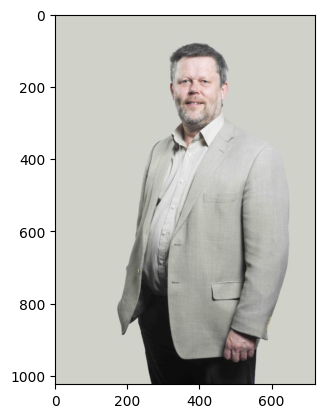

In [3]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os

import torchvision

file_names, images_temp = get_images()
process_values(file_names, images_temp)
processed = decode_images()

file = r'C:/Users/Tanis/Downloads/Europe-Fashion/data/Fashion_Images/image_data/train'
hey = 0

def get_image(img, image):
    cropped = image.crop(processed[img][2])
    plt.imshow(cropped)
    #image = torchvision.transforms.v2.functional.crop(tensor, processed[img][2]) crop with this
    print(processed[img][0])
    print(processed[img][1])

for hi, dir, idk in os.walk(file):
    for i in idk:
        with open(file + '/' + i, 'rb') as f:
            img = Image.open(f)
            plt.imshow(img)
            get_image(i, img)

        break
    